In [39]:
import os
import glob
import numpy as np
import scipy.io as sio
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader

In [25]:
class GestureSequenceDataset(Dataset):
    def __init__(self, root_dir, transform=None, pre_transform=None):
        super(GestureSequenceDataset, self).__init__(root_dir, transform, pre_transform)
        self.root_dir = root_dir
        self.mat_files = glob.glob(os.path.join(root_dir, '*.mat'))
        
        self.label_to_id = {} 
        self.current_id = 0 # Não precisamos mais de "background" solto
        
        # Agora a lista de dados guarda SEQUÊNCIAS (Gestos completos) e não frames soltos
        self.data_list = self._process_all_files()

    def _process_all_files(self):
        all_sequences = []
        
        for filepath in self.mat_files:
            mat_data = sio.loadmat(filepath, squeeze_me=True, struct_as_record=False)
            video = mat_data['Video']
            frames = np.atleast_1d(video.Frames)
            
            # Se não tiver labels anotados, ignora este vídeo
            if not hasattr(video, 'Labels'):
                continue
                
            labels = np.atleast_1d(video.Labels)
            
            # ITERA SOBRE OS INTERVALOS (GESTOS) E NÃO SOBRE OS FRAMES SOLTOS
            for segment in labels:
                nome_gesto = segment.Name
                # Matlab começa no 1, Python no 0. Subtraímos 1 para acessar a lista.
                # O End não subtraímos no limite superior do slice porque o Python exclui o último.
                start_idx = segment.Begin - 1
                end_idx = segment.End 
                
                # Recorta apenas os frames daquele gesto específico
                frames_do_gesto = frames[start_idx:end_idx]
                
                sequencia_coordenadas = []
                
                for frame in frames_do_gesto:
                    if hasattr(frame, 'Skeleton') and hasattr(frame.Skeleton, 'PixelPosition'):
                        pos = frame.Skeleton.PixelPosition
                        if isinstance(pos, np.ndarray) and pos.ndim == 2 and pos.shape[0] == 20:
                            sequencia_coordenadas.append(pos)
                
                # Se conseguimos extrair as coordenadas deste intervalo
                if len(sequencia_coordenadas) > 0:
                    
                    # Empilha todos os frames: shape final será [T, 20, 2]
                    # T = número de frames do gesto
                    x_seq = torch.tensor(np.array(sequencia_coordenadas), dtype=torch.float)
                    
                    centro_de_massa = x_seq.mean(dim=1, keepdim=True) 

                    # 2. Subtrai o centro de massa. Agora o esqueleto está sempre na coordenada (0,0)!
                    x_seq = x_seq - centro_de_massa

                    # 3. Divide pelo desvio padrão para que a altura/largura da pessoa fique numa escala normalizada
                    x_seq = x_seq / (x_seq.std() + 1e-5)

                    # Gerencia o ID numérico da classe
                    if nome_gesto not in self.label_to_id:
                        self.label_to_id[nome_gesto] = self.current_id
                        self.current_id += 1
                        
                    y_val = self.label_to_id[nome_gesto]
                    y = torch.tensor([y_val], dtype=torch.long)
                    
                    # No Graph Structure Learning para sequências, as arestas são geradas
                    # pelo seu modelo baseando-se na matriz X.
                    # Passamos edge_index vazio pois seu modelo vai aprender as conexões.
                    empty_edge_index = torch.empty((2, 0), dtype=torch.long)
                    
                    # Cria a amostra representando o GESTO INTEIRO
                    graph_data = Data(x=x_seq, edge_index=empty_edge_index, y=y)
                    all_sequences.append(graph_data)
                        
        return all_sequences

    def len(self):
        return len(self.data_list)

    def get(self, idx):
        return self.data_list[idx]

In [26]:
dataset = GestureSequenceDataset(root_dir='apenas_mats_train')

In [ ]:
import torch
from torch.utils.data import random_split

total_amostras = len(dataset)

tamanho_treino = int(0.70 * total_amostras)
tamanho_val = int(0.15 * total_amostras)
tamanho_teste = total_amostras - tamanho_treino - tamanho_val 

print(f"Divisão: Treino ({tamanho_treino}), Validação ({tamanho_val}), Teste ({tamanho_teste})")

dataset_treino, dataset_val, dataset_teste = random_split(
    dataset, 
    [tamanho_treino, tamanho_val, tamanho_teste],
)

Divisão: Treino (5427), Validação (1163), Teste (1164)


In [ ]:
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence

def preencher_lote_collate_fn(lista_de_grafos):
    xs = [grafo.x for grafo in lista_de_grafos] 
    ys = [grafo.y for grafo in lista_de_grafos] 
    
    tamanhos_reais = torch.tensor([len(x) for x in xs], dtype=torch.long)
    
    x_padded = pad_sequence(xs, batch_first=True, padding_value=0.0)
    
    y_batched = torch.cat(ys)
    
    return x_padded, y_batched, tamanhos_reais


loader_treino = DataLoader(
    dataset_treino, 
    batch_size=32, 
    shuffle=True, 
    collate_fn=preencher_lote_collate_fn
)

loader_val = DataLoader(dataset_val, batch_size=32, shuffle=False, collate_fn=preencher_lote_collate_fn)
loader_teste = DataLoader(dataset_teste, batch_size=32, shuffle=False, collate_fn=preencher_lote_collate_fn)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import DenseGCNConv

class GestureGSLModel(nn.Module):
    def __init__(self, num_nodes=20, in_features=2, num_classes=20):
        super().__init__()
        
        adj = torch.rand((num_nodes, num_nodes)) * 0.04 + 0.01
        self.adj_param = nn.Parameter(adj)
        
        self.gcn1 = DenseGCNConv(in_features, 16)
        self.gcn2 = DenseGCNConv(16, 32)
        
        self.classifier = nn.Linear(32, num_classes)

    def normalize_adj(self, adj):
        adj_positive = F.relu(adj)
        adj_sym = adj_positive + adj_positive.transpose(-2, -1)
        
        eye = torch.eye(adj_sym.size(-1), device=adj_sym.device)
        adj_hat = adj_sym + eye
        deg = adj_hat.sum(dim=-1)
        deg_inv_sqrt = deg.pow(-0.5)
        deg_inv_sqrt.masked_fill_(deg_inv_sqrt == float('inf'), 0)
        return deg_inv_sqrt.unsqueeze(-1) * adj_hat * deg_inv_sqrt.unsqueeze(1)
    
    def forward(self, x_padded, mask):
        # x_padded shape: [Batch, T, 20, 2] (ex: [32, 80, 20, 2])
        # mask shape: [Batch, T]
        B, T, N, C = x_padded.shape
        
        # --- PREPARAÇÃO DO GRAFO APRENDIDO ---
        adj_norm = self.normalize_adj(self.adj_param) # Shape: [20, 20]
        
        # O DenseGCNConv espera a mesma adjacência para cada item do lote.
        # Nós expandimos de [20, 20] para [Batch*T, 20, 20]
        adj_batch = adj_norm.unsqueeze(0).expand(B * T, N, N)
        
        # --- CONVOLUÇÃO ESPACIAL ---
        # Achata Batch e Tempo para processar cada frame como um grafo isolado
        x = x_padded.view(B * T, N, C) # Shape: [2560, 20, 2]
        
        x = self.gcn1(x, adj_batch, add_loop=False)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        
        x = self.gcn2(x, adj_batch, add_loop=False)
        x = F.relu(x) # Shape de saída: [2560, 20, 32]
        
        # --- DESACHATANDO PARA O FORMATO ORIGINAL ---
        x = x.view(B, T, N, -1) # Shape: [Batch, T, 20, 32]
        
        # --- APLICANDO A MÁSCARA ---
        # Zera os frames de "padding" que inventamos, para que não poluam a decisão
        mask_expanded = mask.unsqueeze(-1).unsqueeze(-1).expand_as(x)
        x = x * mask_expanded.float()
        
        # --- POOLING ESPACIAL (Agrupa as 20 juntas) ---
        # Faz a média das features das 20 juntas do esqueleto
        x_spatial = x.mean(dim=2) # Shape: [Batch, T, 32]
        
        # --- POOLING TEMPORAL (Agrupa os frames do vídeo) ---
        # Somamos todos os frames do vídeo
        soma_temporal = x_spatial.sum(dim=1) # Shape: [Batch, 32]
        
        # Descobrimos quantos frames REAIS cada vídeo teve usando a máscara
        tamanhos_reais = mask.sum(dim=1, keepdim=True).float() # Shape: [Batch, 1]
        
        # Tiramos a média APENAS sobre os frames que realmente existiram
        x_temporal = soma_temporal / tamanhos_reais.clamp(min=1) # Shape: [Batch, 32]
        
        # --- CLASSIFICAÇÃO ---
        out = self.classifier(x_temporal) # Shape final: [Batch, 20]
        
        return out

In [30]:
lote_x, lote_y, lote_tamanhos = next(iter(loader_treino))

print(f"Shape do Lote X preenchido: {lote_x.shape} -> [Tamanho do Lote, Maior T do Lote, 20, 2]")
print(f"Labels do Lote Y: {lote_y.shape}")
print(f"Tamanhos reais antes do zero: {lote_tamanhos}")

Shape do Lote X preenchido: torch.Size([32, 80, 20, 2]) -> [Tamanho do Lote, Maior T do Lote, 20, 2]
Labels do Lote Y: torch.Size([32])
Tamanhos reais antes do zero: tensor([43, 65, 31, 60, 45, 31, 50, 47, 42, 59, 40, 25, 35, 37, 34, 80, 40, 47,
        25, 42, 40, 60, 60, 80, 80, 40, 80, 48, 60, 40, 80, 60])


Treinando na unidade: cuda
Iniciando o treinamento...



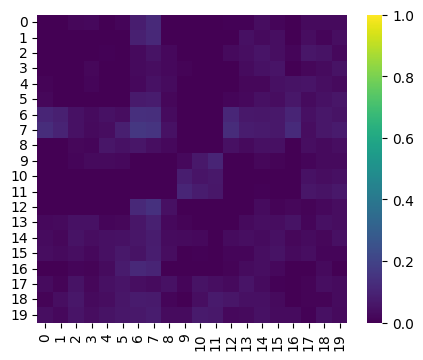

Época [1/100] | Loss Treino: 2.9987 - Acc Treino: 0.0566 | Loss Val: 2.9956 - Acc Val: 0.0585


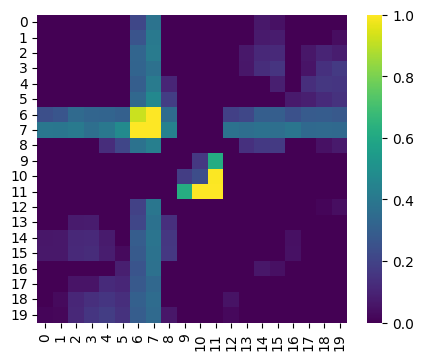

Época [6/100] | Loss Treino: 2.5507 - Acc Treino: 0.1894 | Loss Val: 2.5065 - Acc Val: 0.1754


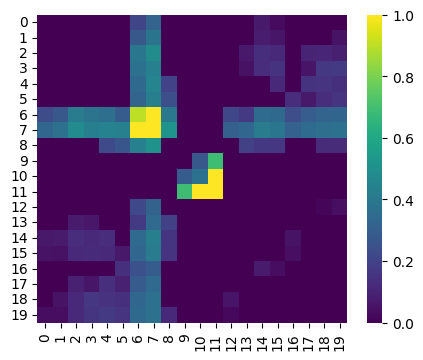

Época [11/100] | Loss Treino: 2.3443 - Acc Treino: 0.2506 | Loss Val: 2.3097 - Acc Val: 0.2580


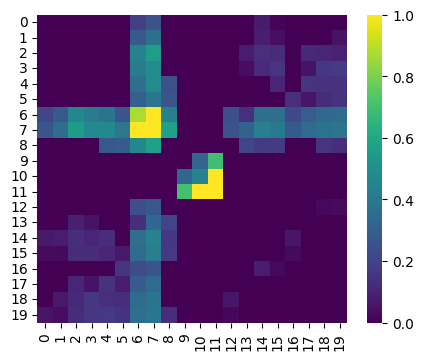

Época [16/100] | Loss Treino: 2.2496 - Acc Treino: 0.2768 | Loss Val: 2.2239 - Acc Val: 0.2760


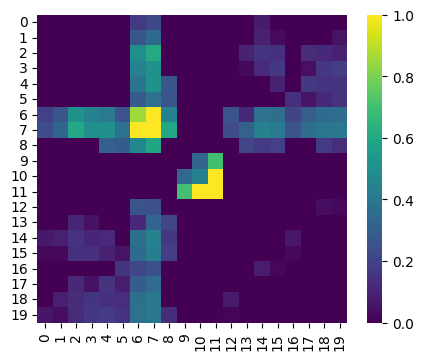

Época [21/100] | Loss Treino: 2.1796 - Acc Treino: 0.2961 | Loss Val: 2.1497 - Acc Val: 0.2975


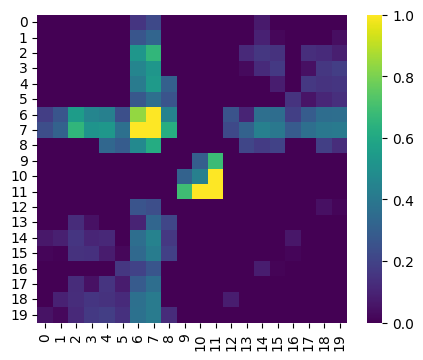

Época [26/100] | Loss Treino: 2.1219 - Acc Treino: 0.3175 | Loss Val: 2.0892 - Acc Val: 0.3164


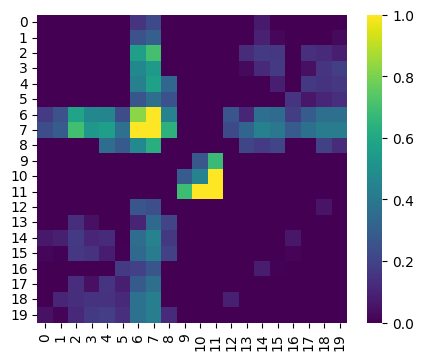

Época [31/100] | Loss Treino: 2.0711 - Acc Treino: 0.3287 | Loss Val: 2.0489 - Acc Val: 0.3353


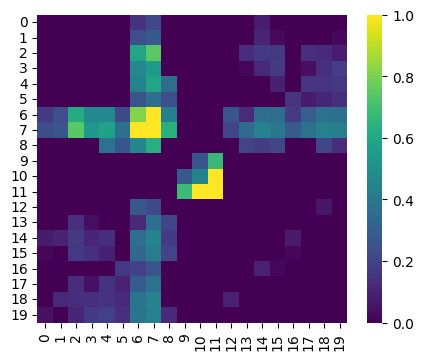

Época [36/100] | Loss Treino: 2.0254 - Acc Treino: 0.3512 | Loss Val: 1.9905 - Acc Val: 0.3362


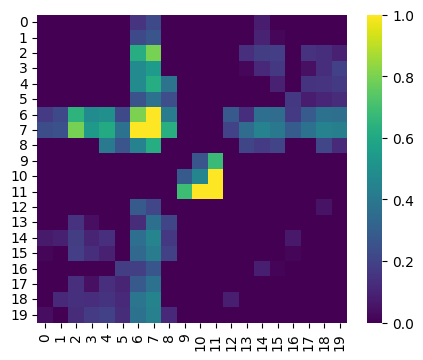

Época [41/100] | Loss Treino: 1.9889 - Acc Treino: 0.3571 | Loss Val: 1.9592 - Acc Val: 0.3551


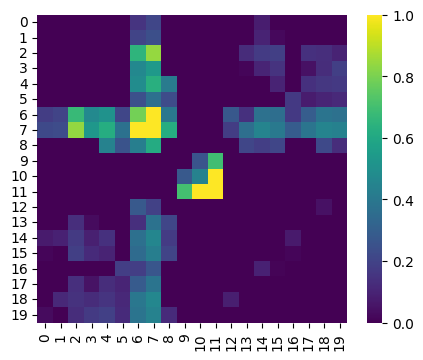

Época [46/100] | Loss Treino: 1.9538 - Acc Treino: 0.3676 | Loss Val: 1.9051 - Acc Val: 0.3594


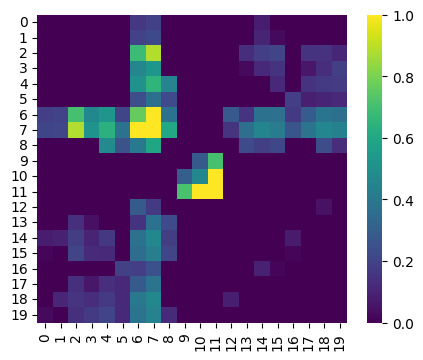

Época [51/100] | Loss Treino: 1.9253 - Acc Treino: 0.3812 | Loss Val: 1.8748 - Acc Val: 0.3637


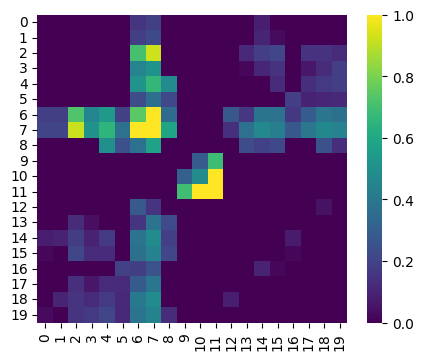

Época [56/100] | Loss Treino: 1.8969 - Acc Treino: 0.3903 | Loss Val: 1.8450 - Acc Val: 0.3740


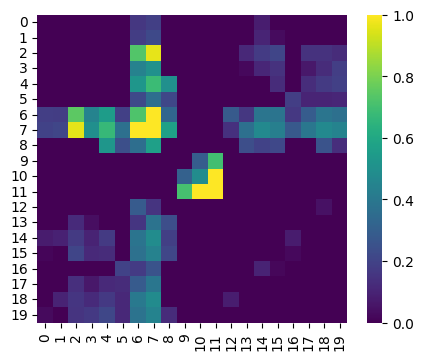

Época [61/100] | Loss Treino: 1.8669 - Acc Treino: 0.4034 | Loss Val: 1.8205 - Acc Val: 0.3835


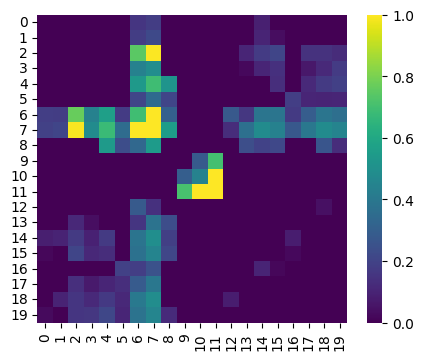

Época [66/100] | Loss Treino: 1.8445 - Acc Treino: 0.4026 | Loss Val: 1.7865 - Acc Val: 0.3878


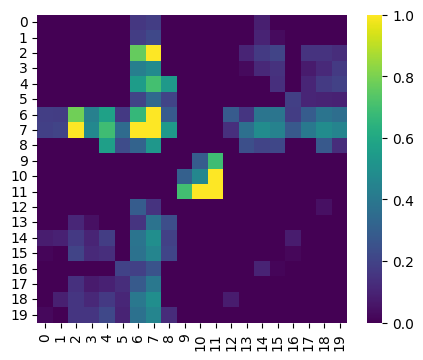

Época [71/100] | Loss Treino: 1.8243 - Acc Treino: 0.4059 | Loss Val: 1.7733 - Acc Val: 0.3998


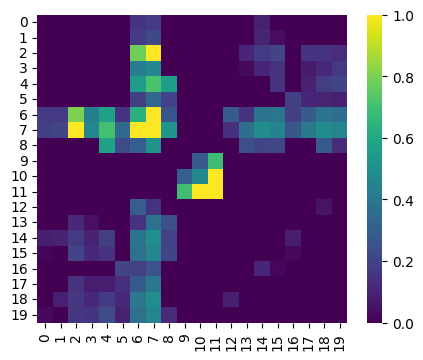

Época [76/100] | Loss Treino: 1.8064 - Acc Treino: 0.4229 | Loss Val: 1.7589 - Acc Val: 0.4084


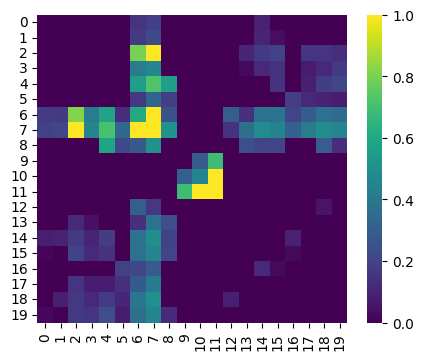

Época [81/100] | Loss Treino: 1.7918 - Acc Treino: 0.4247 | Loss Val: 1.7381 - Acc Val: 0.4058


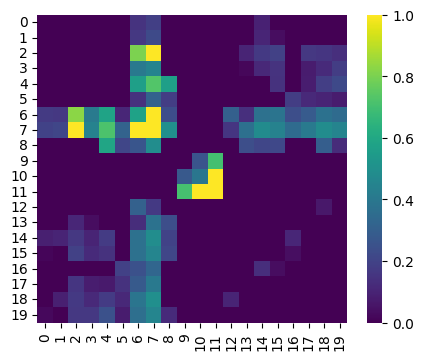

Época [86/100] | Loss Treino: 1.7755 - Acc Treino: 0.4238 | Loss Val: 1.7125 - Acc Val: 0.4153


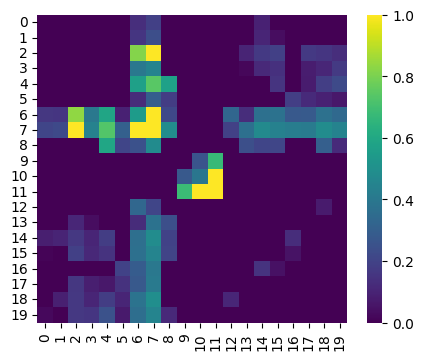

Época [91/100] | Loss Treino: 1.7690 - Acc Treino: 0.4306 | Loss Val: 1.7001 - Acc Val: 0.4299


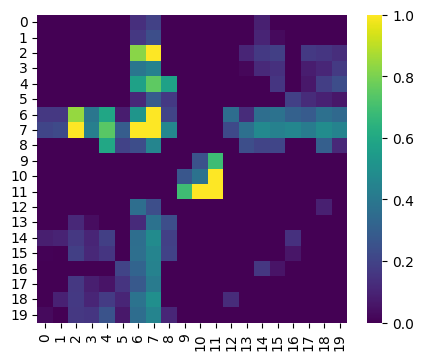

Época [96/100] | Loss Treino: 1.7556 - Acc Treino: 0.4310 | Loss Val: 1.6931 - Acc Val: 0.4282

Treinamento Finalizado!


In [ ]:
import torch.optim as optim
import torch.nn as nn

modelo = GestureGSLModel(num_nodes=20, in_features=2, num_classes=20)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Treinando na unidade: {device}")

modelo = modelo.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(modelo.parameters(), lr=0.001)

num_epocas = 100 

for epoca in range(num_epocas):
    modelo.train()
    loss_treino_acumulada = 0.0
    acertos_treino = 0
    total_treino = 0
    
    for x_padded, y_batched, tamanhos_reais in loader_treino:
        x_padded = x_padded.to(device)
        y_batched = y_batched.to(device)
        tamanhos_reais = tamanhos_reais.to(device)
        
        # Cria a máscara no mesmo device
        B, T = x_padded.shape[0], x_padded.shape[1]
        posicoes = torch.arange(T, device=device).unsqueeze(0).expand(B, T)
        mask = posicoes < tamanhos_reais.unsqueeze(1)
        
        optimizer.zero_grad()
        
        previsoes = modelo(x_padded, mask)
        
        loss = criterion(previsoes, y_batched)
        
        loss.backward()
        
        optimizer.step()
        
        loss_treino_acumulada += loss.item()
        
        _, classe_prevista = torch.max(previsoes, 1)
        acertos_treino += (classe_prevista == y_batched).sum().item()
        total_treino += y_batched.size(0)

    acc_treino = acertos_treino / total_treino
    loss_media_treino = loss_treino_acumulada / len(loader_treino)
    
    modelo.eval()
    loss_val_acumulada = 0.0
    acertos_val = 0
    total_val = 0
    
    with torch.no_grad(): 
        for x_padded, y_batched, tamanhos_reais in loader_val:
            x_padded = x_padded.to(device)
            y_batched = y_batched.to(device)
            tamanhos_reais = tamanhos_reais.to(device)
            
            B, T = x_padded.shape[0], x_padded.shape[1]
            posicoes = torch.arange(T, device=device).unsqueeze(0).expand(B, T)
            mask = posicoes < tamanhos_reais.unsqueeze(1)
            
            previsoes = modelo(x_padded, mask)
            loss = criterion(previsoes, y_batched)
            
            loss_val_acumulada += loss.item()
            _, classe_prevista = torch.max(previsoes, 1)
            acertos_val += (classe_prevista == y_batched).sum().item()
            total_val += y_batched.size(0)
            
    acc_val = acertos_val / total_val
    loss_media_val = loss_val_acumulada / len(loader_val)
    
    if epoca % 5 == 0:
        adj = modelo.adj_param.detach().cpu().numpy()
        plt.figure(figsize=(5, 4))
        sns.heatmap(adj, cmap="viridis", vmin=0, vmax=1)
        plt.show()
        print(f"Época [{epoca+1}/{num_epocas}] | "
            f"Loss Treino: {loss_media_treino:.4f} - Acc Treino: {acc_treino:.4f} | "
            f"Loss Val: {loss_media_val:.4f} - Acc Val: {acc_val:.4f}")

print("\nTreinamento Finalizado!")

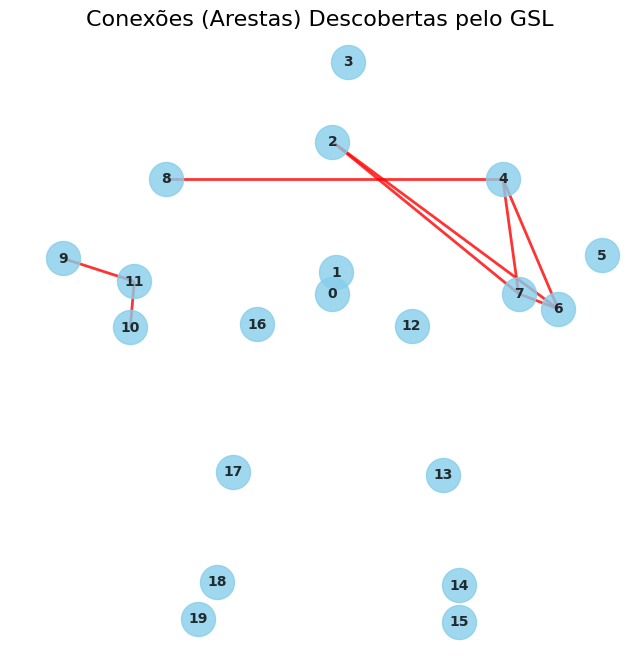

In [ ]:
from torch_geometric.utils import dense_to_sparse
from torch_geometric.data import Data 
from torch_geometric.utils import to_networkx

modelo.eval()
adj_aprendida = F.relu(modelo.adj_param).detach().cpu()

limiar = 0.5 
adj_filtrada = torch.where(adj_aprendida > limiar, torch.tensor(1.0), torch.tensor(0.0))

adj_filtrada.fill_diagonal_(0)

edge_index, _ = dense_to_sparse(adj_filtrada)
data_view = Data(edge_index=edge_index, num_nodes=20)
G = to_networkx(data_view, to_undirected=True)

amostra_base = dataset_teste[0]
coordenadas_reais = amostra_base.x[0].numpy()

posicoes_esqueleto = {i: (coordenadas_reais[i, 0], coordenadas_reais[i, 1]) for i in range(20)}

plt.figure(figsize=(8, 8))
plt.title("Conexões (Arestas) Descobertas pelo GSL", fontsize=16)
plt.axis('off')

nx.draw_networkx(
    G,
    pos=posicoes_esqueleto, 
    with_labels=True,
    node_size=600,
    node_color="skyblue",
    font_size=10,
    font_weight="bold",
    edge_color="red",     
    width=1.0,            
    alpha=0.8
)

plt.gca().invert_yaxis()
plt.show()